# _Numericl Weather Map Analysis_

## Bergthórsson e Döös, 1955

Este notebook apresenta dois exemplos da aplicação das ideias de Bergthórsson e Döös (1955) para a determinação de uma análise utilizando um background, observações e pesos determinados de forma empírica.

A análise de Bergthórsson e Döös (1955) tinha como características:

* Pesos empíricos são atribuídos ao background e observações (função da distância entre o ponto de grade e ponto da observação);
* Erros não correlacionados entre background e observações;
* Erro do background é homogêneo (igual em todos os pontos de grade) e a variância é independente do local;
* O erro da observação é espacialmente não correlacionado (cada estação tem o seu erro) e é uma função apenas do erro do instrumento.

Na formulação do problema para a determinação da análise, considera-se uma única observação no ponto $\mathbf{r}_{k}$ e duas estimativas de $f$ no ponto de grade $\mathbf{r}_{i}$:

$$
f_{B}(\mathbf{r}_{i})
$$

$$
f_{B}(\mathbf{r}_{i}) + [f_{O}(\mathbf{r}_{k}) - f_{B}(\mathbf{r}_{k})]
$$

* Onde,
  * $f_{B}(\mathbf{r}_{i})$ é o background no ponto de grade $\mathbf{r}_{i}$;
  * $f_{O}(\mathbf{r}_{k}) - f_{B}(\mathbf{r}_{k})$ é a diferença entre a observação $f_{O}(\mathbf{r}_{k})$ e o background $f_{B}(\mathbf{r}_{k})$, sendo esta diferença constante ao longo da curva que une os pontos de grade $\mathbf{r}_{k}$ e $\mathbf{r}_{i}$. 

A análise de Bergthórsson e Döös combina estas duas estimativas da seguinte forma:

$$
f_{A}(\mathbf{r}_{i}) = f_{B}(\mathbf{r}_{i}) + W[f_{O}(\mathbf{r}_{k}) - f_{B}(\mathbf{r}_{k})]
$$

$$
W = \frac{E_{O}^{-2}(k)w(\mathbf{r}_{k} - \mathbf{r}_{i})}{E_{B}^{-2}+E_{O}^{-2}(k)w(\mathbf{r}_{k} - \mathbf{r}_{i})}
$$

A partir disso, pode-se avaliar a influência do peso $w$ nos pontos de grade $\mathbf{r}_{k}$ e $\mathbf{r}_{i}$. O que acontece quanto às posições relativas do ponto de estação e do ponto de grade:

* Quando $\mathbf{r}_{k} = \mathbf{r}_{i}$ (pontos de grade e estação coincidem), então $w(\mathbf{r}_{k}-\mathbf{r}_{i}) = 1$
* Quando $|\mathbf{r}_{k} - \mathbf{r}_{i}| \to \infty$ (distância entre os pontos aumenta), então $w(\mathbf{r}_{k}-\mathbf{r}_{i}) \to 0$

## Exemplo 1D

### Definição do modelo

Vamos iniciar com um exemplo em 1 dimensão. Para isto, vamos utilizar um modelo simples, definido como a função seno com a adição de um ruído normalmente distribuído (com desvio-padrão $\sigma = 0,5$) $f(x) = \sin(x) + \varepsilon, \quad \varepsilon \sim \mathcal{N}(0, \sigma^2), \quad -\pi \le x \le \pi$:

In [22]:
import numpy as np
import matplotlib.pyplot as plt

In [23]:
x = np.arange(-np.pi, np.pi, 0.01)
xb_seno = np.sin(x)

sigma = 0.5  # desvio-padrão do ruído
ruido = np.random.randn(*x.shape) * sigma

# adicionando o ruído ruído
xb = xb_seno + ruido

### Determinação das observações

In [24]:
# Posições
obs_pos = np.array([-2.2, -2.1, -2.0, -1.8, 0.9, 1, 2, 3])

# Valores medidos
obs_vals = np.array([-2.2, -1.8, 0.9, 0, 1, 2, 3, 4]) 

### Determinação dos pesos

In [25]:
# L tem a função de w na formulação do problema de análise de Bergthórsson e Döös
L=0.5

# Função de peso Gaussiana (influência da observação)
def weight(dx, L=L):
    return np.exp(-(dx**2)/(2*L**2))

# Inicializa análise como background
xa = xb.copy()

# Aplica correção observação por observação
for xo, yo in zip(obs_pos, obs_vals):
    dx = x - xo
    w = weight(dx, L=L)
    xa = (1-w)*xa + w*yo

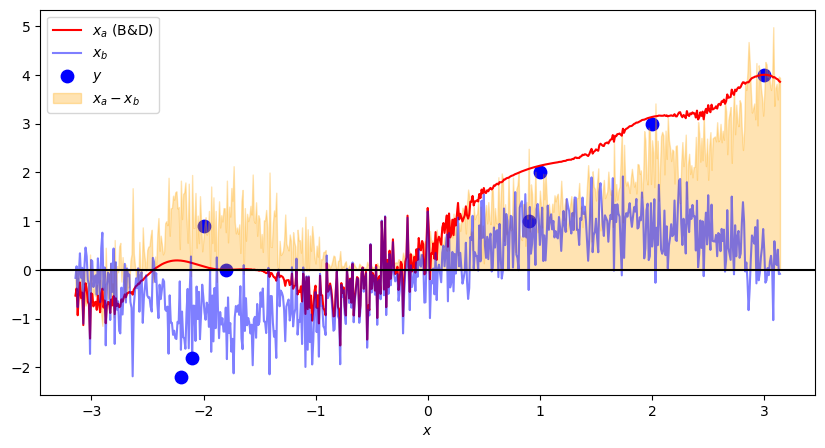

In [26]:
plt.figure(figsize=(10,5))
plt.plot(x, xa, 'r-', label="$x_{a}$ (B&D)")
plt.plot(x, xb, 'b-', label="$x_{b}$", alpha=0.5)
plt.scatter(obs_pos, obs_vals, c='blue', s=80, marker='o', label="$y$")
plt.fill_between(x, xa-xb, 0, color="orange", alpha=0.3, label="$x_{a}-x_{b}$")
plt.axhline(y=0, color="k")
plt.legend()
plt.xlabel("$x$")
plt.show()

## Exemplo 2D

### Definição do modelo

Vamos para o exemplo em 2 dimensões. Semelhante ao exemplo anterior, vamos utilizar um modelo simples, definido como a função seno com a adição de um ruído normalmente distribuído (com desvio-padrão $\sigma = 0,5$) $f(x,y) = \sin(x) + \varepsilon, \quad \varepsilon \sim \mathcal{N}(0, \sigma^2), \quad -\pi \le x \le \pi, \quad -\pi \le y \le \pi$. Definiremos esta função em um plano Cartesiano de 100 pontos:

In [35]:
# Grade onde queremos analisar (lat x lon simples)
lon = np.linspace(-np.pi, np.pi, 10)
lat = np.linspace(-np.pi, np.pi, 10)

LON, LAT = np.meshgrid(lon, lat)

In [36]:
xb_seno = np.sin(LON)

sigma = 0.5  # desvio-padrão do ruído
#ruido = np.random.randn(len(LON)) * sigma 
ruido = np.random.randn(*LON.shape) * sigma # equivalente a np.random.randn(10, 10)

xb = xb_seno + ruido

### Determinação das observações

In [37]:
# Conjunto de observações 1
#
# Posições
#
#obs_locs = np.array([[-2.2, -1],
#                    [-2.1, 0.5],
#                    [-2.0, -0.5],
#                    [-1.8, 2],
#                    [0.9, -2.8],
#                    [1, 1],
#                    [2, 0],
#                    [3, 0.5]])      
#
# Valores medidos
#
#obs_vals = np.array([-1.0, -1.5, -2.0, -1, 1, 0, 0.5, 0]) 

In [38]:
# Conjunto de observações 2
#
# Posições
#
#obs_locs = np.array([[-2, -2],
#                    [-1, -1],
#                    [0, 0],
#                    [1, 1],
#                    [2, 2]])      
# Valores medidos
#
#obs_vals = np.array([-1.0, -1.5, -1.0, 0, -0.5])  

In [39]:
# Conjunto de observações 3
#
# Posições

obs_locs = np.array([[-2, -2],
                    [0, 0],
                    [2, 2]]) 

# Valores medidos

obs_vals = np.array([-1.5, -1.0, 0.5]) 

### Determinação dos pesos

In [40]:
# L tem a função de w na formulação do problema de análise de Bergthórsson e Döös
L=1.5

# Função de peso (correlação) - tipo Gaussiana
def weight(dx, dy, L=L):    
    return np.exp(-(dx**2 + dy**2)/(2*L**2))

# Inicializa análise como background
xa = xb.copy()

# Aplica a correção observação por observação
for (xo, yo), obs in zip(obs_locs, obs_vals):
    dx = LON - xo
    dy = LAT - yo
    w = weight(dx, dy, L=L)  
    xa = (1-w) * xa + w * obs

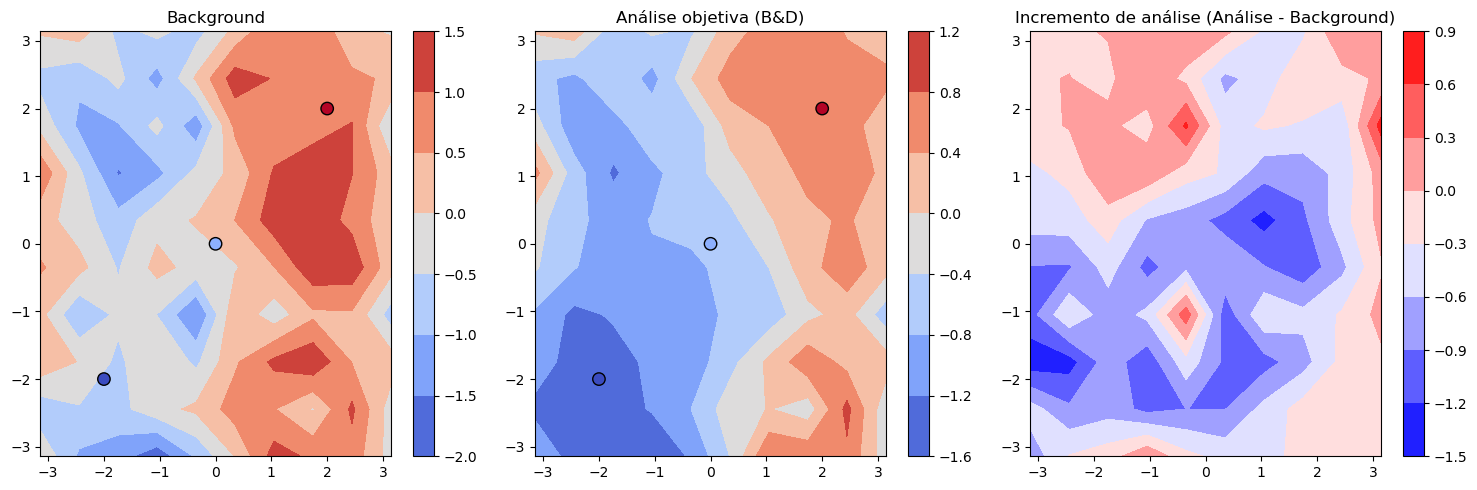

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(15,5))
cs0 = axes[0].contourf(LON, LAT, xb, cmap="coolwarm")
axes[0].scatter(obs_locs[:,0], obs_locs[:,1], c=obs_vals, edgecolor="k", cmap="coolwarm", s=80)
axes[0].set_title("Background")
fig.colorbar(cs0, ax=axes[0])

cs1 = axes[1].contourf(LON, LAT, xa, cmap="coolwarm")
axes[1].scatter(obs_locs[:,0], obs_locs[:,1], c=obs_vals, edgecolor="k", cmap="coolwarm", s=80)
axes[1].set_title("Análise objetiva (B&D)")
fig.colorbar(cs1, ax=axes[1])

cs2 = axes[2].contourf(LON, LAT, xa-xb, cmap="bwr")
axes[2].set_title("Incremento de análise (Análise - Background)")
fig.colorbar(cs2, ax=axes[2])

plt.tight_layout()
plt.show()

## Papel do $L$ na análise de Bergthórsson & Döös (1955)

$L$ controla o "alcance" das observações sobre a análise. O peso $w$ utilizado no programa, possui a seguinte fórmula:

$$
w = {e}^{ -\frac{dx^{2}}{2L^{2}}} 
$$

Onde:

* $dx$ é a distância entre ponto de grade e observação,
* $L$ é o parâmetro de suavização.

Se $L$ é pequeno, então a influência da observação cai muito rápido, logo cada observação só afeta a vizinhança imediata e, portanto, análise fica mais "pontiaguda".

Imagine que você tem uma observação em $x=10$:

* Se $L=1$, ela só afeta bem o intervalo [9,11].
* Se $L=5$, ela influencia quase todo o domínio.

## Perguntas

Para ambos os casos (1D e 2D):

1. O que acontece com a análise quando $L$ é muito pequeno ou muito grande? No exemplo dado, qual o intervalo de $L$ produz os melhores resultados (i.e., permite maior contribuição das observações)?
2. Qual é o papel de $L$?
3. O que acontece nas regiões onde as observações são mais próximas?
4. O que acontece nas regiões onde as observações não ocorrem?